<div style="background:linear-gradient(135deg,#2e1065 0%,#6d28d9 55%,#8b5cf6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 44 · Mathematical Statistics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Conditional Expectation &amp; the Tower Property 🗼</div>
  <div style="font-size:15px;color:#ede9fe;max-width:740px;line-height:1.6">The best prediction of one variable given another. This notebook computes conditional expectations, verifies the tower property E[E[Y|X]] = E[Y], decomposes variance, and shows that E[Y|X] is exactly what regression estimates.</div>
  <div style="margin-top:16px;font-size:13px;color:#c4b5fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(44)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
VIOLET="#7c3aed"; PINK="#db2777"; TEAL="#0d9488"
print("ready")

ready


<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 1 · CONDITIONAL EXPECTATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The average of Y, given X</div>
<div style="color:#4a5578;margin-top:6px">E[Y | X = x] is the mean of Y restricted to the cases where X = x. It is a FUNCTION of x: a different average for each value of the conditioning variable.</div>
</div>

In [2]:
# spending given customer segment
rng2 = np.random.default_rng(7)
segment = rng2.integers(0,3,size=30_000)            # 0,1,2
true_means = np.array([20., 50., 90.])
spend = rng2.normal(true_means[segment], 10)
for k in range(3):
    print(f"E[spend | segment={k}] = {spend[segment==k].mean():.2f}  (true {true_means[k]:.0f})")

E[spend | segment=0] = 19.88  (true 20)
E[spend | segment=1] = 49.98  (true 50)
E[spend | segment=2] = 89.88  (true 90)


The conditional expectation is not one number but a rule: given segment 0 expect about 20, segment 1 about 50, segment 2 about 90. E[Y | X] is a function of X, the best single guess of Y once you know X.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE TOWER PROPERTY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Averaging the averages</div>
<div style="color:#4a5578;margin-top:6px">The tower property (law of total expectation): E[E[Y|X]] = E[Y]. If you average the conditional means, weighted by how often each X occurs, you recover the overall mean of Y.</div>
</div>

In [3]:
overall = spend.mean()
# average the conditional means weighted by segment frequency
weights = np.array([(segment==k).mean() for k in range(3)])
cond_means = np.array([spend[segment==k].mean() for k in range(3)])
tower = (weights*cond_means).sum()
print(f"E[Y] directly           = {overall:.3f}")
print(f"E[E[Y|X]] (tower)        = {tower:.3f}")
print(f"match? {np.isclose(overall, tower, atol=1e-9)}")

E[Y] directly           = 53.502
E[E[Y|X]] (tower)        = 53.502
match? True


Both routes give the same number. The **tower property** says you can compute E[Y] either directly, or in two stages: first average within each group (the conditional expectations), then average those, weighted by group size. This "average of averages" is one of the most-used tricks in probability.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 3 · E[Y|X] IS THE BEST PREDICTOR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Minimizing squared error</div>
<div style="color:#4a5578;margin-top:6px">Among ALL functions of X, the conditional expectation E[Y|X] is the one that minimizes the mean squared error in predicting Y. It is the theoretical target of regression.</div>
</div>

In [4]:
# compare E[Y|X] to other constant-per-group guesses by MSE
pred_condexp = cond_means[segment]            # use the conditional mean for each row
pred_overall = np.full_like(spend, overall)   # ignore X, always guess the global mean
mse_condexp = ((spend - pred_condexp)**2).mean()
mse_overall = ((spend - pred_overall)**2).mean()
print(f"MSE using E[Y|X]     = {mse_condexp:.2f}")
print(f"MSE using E[Y] only  = {mse_overall:.2f}")
print(f"-> conditioning on X cuts the error substantially")

MSE using E[Y|X]     = 99.40
MSE using E[Y] only  = 925.09
-> conditioning on X cuts the error substantially


Using the conditional mean for each segment gives far lower squared error than ignoring X and guessing the global average. This is the precise sense in which **E[Y | X] is the best predictor of Y**: no function of X can beat it on mean squared error. Regression is, at heart, an attempt to estimate this function.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 4 · THE LAW OF TOTAL VARIANCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Splitting the variance</div>
<div style="color:#4a5578;margin-top:6px">Variance decomposes too: Var(Y) = E[Var(Y|X)] + Var(E[Y|X]). The total spread of Y is the average within-group spread PLUS the spread between the group means.</div>
</div>

In [5]:
var_within  = sum(weights[k]*spend[segment==k].var() for k in range(3))   # E[Var(Y|X)]
var_between = (weights*(cond_means - overall)**2).sum()                    # Var(E[Y|X])
print(f"Var(Y) total           = {spend.var():.2f}")
print(f"E[Var(Y|X)] (within)   = {var_within:.2f}")
print(f"Var(E[Y|X]) (between)  = {var_between:.2f}")
print(f"within + between       = {var_within+var_between:.2f}")

Var(Y) total           = 925.09
E[Var(Y|X)] (within)   = 99.40
Var(E[Y|X]) (between)  = 825.69
within + between       = 925.09


The total variance of spending splits cleanly into the **within-segment** variance (noise around each group mean, here from the sd of 10) and the **between-segment** variance (how far the group means sit from the overall mean). This law of total variance is the foundation of ANOVA and of the bias-variance story in machine learning.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 5 · CONDITIONAL EXPECTATION IS REGRESSION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What every model estimates</div>
<div style="color:#4a5578;margin-top:6px">Regression, from linear models to deep networks, is machinery for estimating E[Y|X]. Here a smooth conditional mean recovered from noisy data IS the regression curve.</div>
</div>

In [6]:
x = rng.uniform(-3, 3, size=4000)
y = np.sin(x) + rng.normal(0, 0.4, size=4000)     # true E[Y|X] = sin(x)
# estimate E[Y|X] by binning (a nonparametric conditional mean)
bins = np.linspace(-3,3,25); idx = np.digitize(x, bins)
centers = 0.5*(bins[:-1]+bins[1:])
cond = [y[idx==i+1].mean() for i in range(len(centers))]
print(f"estimated E[Y|X] near x=0:   {y[(x>-0.2)&(x<0.2)].mean():+.3f}  (true sin(0)=0)")
print(f"estimated E[Y|X] near x=1.57: {y[(x>1.37)&(x<1.77)].mean():+.3f}  (true sin(pi/2)=1)")

estimated E[Y|X] near x=0:   +0.025  (true sin(0)=0)
estimated E[Y|X] near x=1.57: +0.999  (true sin(pi/2)=1)


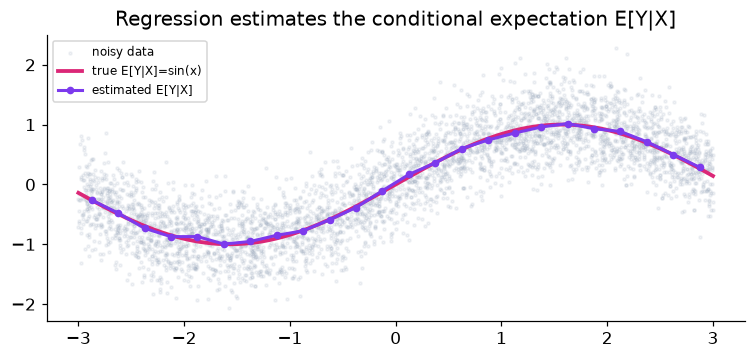

In [7]:
fig,ax=plt.subplots(figsize=(7,3.4))
ax.scatter(x,y,s=4,alpha=0.12,color="#94a3b8",label="noisy data")
xs=np.linspace(-3,3,200); ax.plot(xs,np.sin(xs),color=PINK,lw=2.5,label="true E[Y|X]=sin(x)")
ax.plot(centers,cond,"o-",color=VIOLET,lw=2,ms=4,label="estimated E[Y|X]")
ax.set_title("Regression estimates the conditional expectation E[Y|X]"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The binned conditional means trace out sin(x), the true E[Y | X], recovered from pure noise. Every regression method, ordinary least squares, random forests, neural networks, is an estimator of this same conditional-expectation function. When a model "predicts Y from X", what it is really computing is an estimate of E[Y | X].

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You computed conditional expectations, verified the tower property, showed E[Y|X] is the best predictor, decomposed variance into within and between parts, and recovered a regression curve as an estimated conditional mean. E[Y|X] is the single idea that links probability to prediction.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>